<a href="https://colab.research.google.com/github/ludmila-sla/aulas-mestrado/blob/main/perception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


class Perceptron:
    def __init__(self, lr=0.1, epochs=100, seed=None):
        self.lr = lr
        self.epochs = epochs
        self.seed = seed
        self.w = None
        self.errors = []

    def _add_bias(self, X):
        bias = np.ones((1, X.shape[1]))
        return np.vstack((bias, X))

    def _step_function(self, x):
        return np.where(x >= 0, 1, -1)

    def fit(self, X, y):
        if self.seed:
            np.random.seed(self.seed)

        X = self._add_bias(X)
        n_features = X.shape[0]

        self.w = np.random.randn(n_features, 1)
        self.errors = []

        for _ in range(self.epochs):
            error_count = 0

            for i in range(X.shape[1]):
                xi = X[:, i].reshape(-1, 1)
                yi = y[0, i]

                y_pred = self._step_function(self.w.T @ xi)

                if y_pred != yi:
                    self.w += self.lr * yi * xi
                    error_count += 1

            error_rate = error_count / X.shape[1]
            self.errors.append(error_rate)

        return self.w

    def predict(self, X):
        X = self._add_bias(X)
        y_pred = self._step_function(self.w.T @ X)
        return y_pred

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/trabalho perception/train_dataset1.csv')
df_test = pd.read_csv('/content/drive/MyDrive/trabalho perception/test_dataset1.csv')

X_train = df_train.drop('label', axis=1).values.T
y_train = df_train['label'].values.reshape(1, -1)

X_test = df_test.drop('label', axis=1).values.T
y_test = df_test['label'].values.reshape(1, -1)

Acurácia treino: 0.9571428571428572
Acurácia teste: 0.9333333333333333


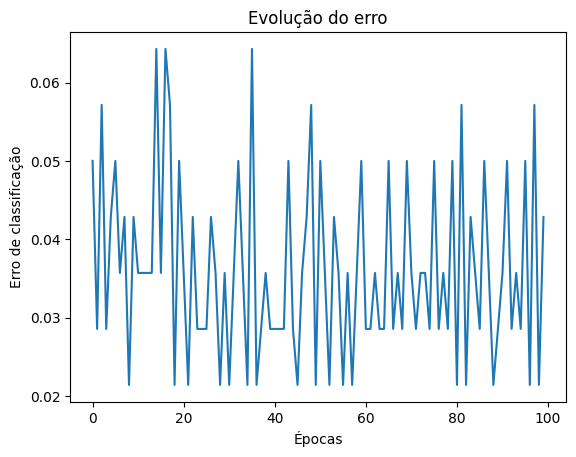

In [ ]:
model = Perceptron(lr=0.1, epochs=100, seed=42)
model.fit(X_train, y_train)

train_acc = model.accuracy(X_train, y_train)
test_acc = model.accuracy(X_test, y_test)

print("Acurácia treino:", train_acc)
print("Acurácia teste:", test_acc)

plt.plot(model.errors)
plt.xlabel("Épocas")
plt.ylabel("Erro de classificação")
plt.title("Evolução do erro")
plt.show()

In [ ]:
def plot_decision_boundary(X, y, model, title):
    plt.scatter(X[0, :], X[1, :], c=y.flatten())

    x_vals = np.linspace(X[0, :].min(), X[0, :].max(), 100)
    w0, w1, w2 = model.w.flatten()

    y_vals = -(w0 + w1 * x_vals) / w2

    plt.plot(x_vals, y_vals, color='red')
    plt.title(title)
    plt.show()

    plot_decision_boundary(X_train, y_train, model, "Treino")
    plot_decision_boundary(X_test, y_test, model, "Teste")

No Dataset 1, o modelo atingiu mais de 90% de acurácia tanto no conjunto de treino quanto no de teste, indicando boa capacidade de aprendizado e generalização. Esse comportamento sugere que os dados são aproximadamente linearmente separáveis.

# Dataset 2

Acurácia treino: 0.5028571428571429
Acurácia teste: 0.49333333333333335


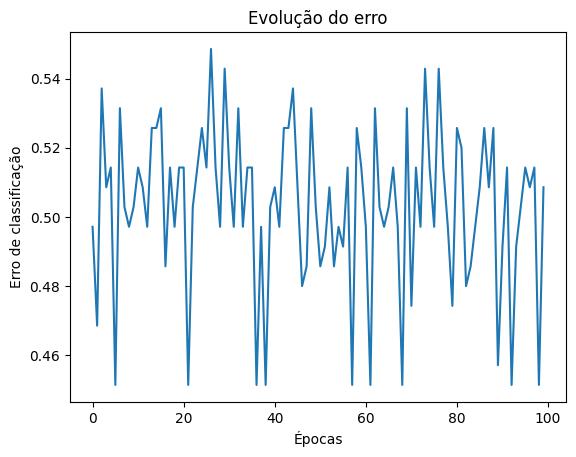

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/trabalho perception/train_dataset2.csv')
df_test = pd.read_csv('/content/drive/MyDrive/trabalho perception/test_dataset2.csv')

X_train = df_train.drop('label', axis=1).values.T
y_train = df_train['label'].values.reshape(1, -1)

X_test = df_test.drop('label', axis=1).values.T
y_test = df_test['label'].values.reshape(1, -1)

model = Perceptron(lr=0.1, epochs=100, seed=42)
model.fit(X_train, y_train)

train_acc = model.accuracy(X_train, y_train)
test_acc = model.accuracy(X_test, y_test)

print("Acurácia treino:", train_acc)
print("Acurácia teste:", test_acc)

plt.plot(model.errors)
plt.xlabel("Épocas")
plt.ylabel("Erro de classificação")
plt.title("Evolução do erro")
plt.show()

def plot_decision_boundary(X, y, model, title):
    plt.scatter(X[0, :], X[1, :], c=y.flatten())

    x_vals = np.linspace(X[0, :].min(), X[0, :].max(), 100)
    w0, w1, w2 = model.w.flatten()

    y_vals = -(w0 + w1 * x_vals) / w2

    plt.plot(x_vals, y_vals, color='red')
    plt.title(title)
    plt.show()

    plot_decision_boundary(X_train, y_train, model, "Treino")
    plot_decision_boundary(X_test, y_test, model, "Teste")

No Dataset 2, a acurácia ficou em torno de 40–50%, além de apresentar comportamento oscilatório no erro. Isso indica que o modelo não conseguiu convergir, mostrando uma limitação do Perceptron ao lidar com dados que não são linearmente separáveis.

# Dataset 3

lr=0.1, epochs=100 -> acc=0.8413
lr=0.1, epochs=200 -> acc=0.9048
lr=0.001, epochs=100 -> acc=0.8413
lr=0.001, epochs=200 -> acc=0.8571
lr=0.0001, epochs=100 -> acc=0.5079
lr=0.0001, epochs=200 -> acc=0.5873


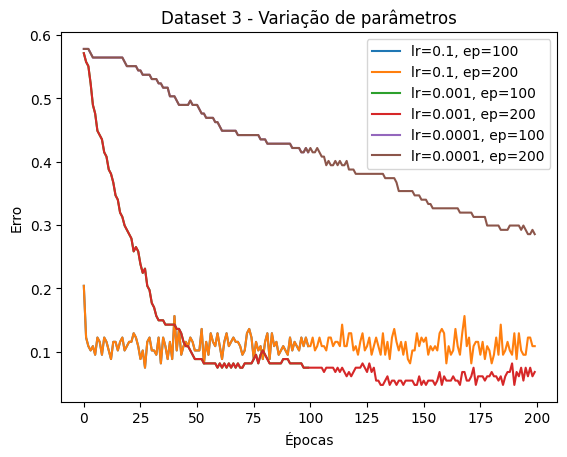

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/trabalho perception/train_dataset3.csv')
df_test = pd.read_csv('/content/drive/MyDrive/trabalho perception/test_dataset3.csv')

X_train = df_train.drop('label', axis=1).values.T
y_train = df_train['label'].values.reshape(1, -1)

X_test = df_test.drop('label', axis=1).values.T
y_test = df_test['label'].values.reshape(1, -1)

learning_rates = [0.1, 0.001, 0.0001]
epochs_list = [100, 200]

results = []

for lr in learning_rates:
    for ep in epochs_list:
        model = Perceptron(lr=lr, epochs=ep, seed=42)
        model.fit(X_train, y_train)

        acc = model.accuracy(X_test, y_test)
        results.append((lr, ep, acc))

        print(f"lr={lr}, epochs={ep} -> acc={acc:.4f}")

        plt.plot(model.errors, label=f"lr={lr}, ep={ep}")
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.legend()
plt.title("Dataset 3 - Variação de parâmetros")
plt.show()

No Dataset 3, os resultados variaram significativamente de acordo com a taxa de aprendizado e o número de épocas. A melhor acurácia foi obtida com taxa de aprendizado 0.1 e 200 épocas, enquanto os piores resultados ocorreram com taxa de aprendizado muito baixa (0.0001). Isso demonstra que taxas de aprendizado muito pequenas tornam o processo de treinamento lento e ineficiente.

De forma geral, os experimentos mostraram que o Perceptron é altamente dependente da linearidade dos dados e da escolha adequada de hiperparâmetros, apresentando bom desempenho em cenários simples, mas limitações em problemas mais complexos.